## EDA numerical features

In this notebook I will perform EDA on numerical features.

#### Columns:
- `tenure`
- `monthly_charges`
- `total_charges`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import scatter_matrix

from telco_churn.config import (
    NUMERICAL_COLUMNS,
    TARGET_COLUMN,
)
from telco_churn.paths import (
    TELCO_CUSTOMERS_TRAIN_PATH,
    EDA_NUMERICAL_DIR,
)
from telco_churn.plots import (
    add_bar_labels,
    save_plot,
)

## Helpers

In [2]:
# Encode churn as a numerical variable
def encode_churn(df, target_column):
    churn_map = {
        'No': 0,
        'Yes': 1,
    }

    return df[target_column].map(churn_map)

# Calculate churn rate baseline
def churn_rate_baseline(df, target_column):
    churn_encoded = encode_churn(
        df=df,
        target_column=target_column,
    )

    return (churn_encoded.mean() * 100).round(2)

# Calculate descriptive statistics for a given column
def descriptive_stats(df, column):
    stats = df[column].describe()
    stats['iqr'] = stats['75%'] - stats['25%']
    stats['nunique'] = df[column].nunique()
    return stats


# Count potential outliers using the IQR method
def iqr_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    iqr_lower = q1 - iqr * 1.5
    iqr_upper = q3 + iqr * 1.5

    outliers_lower_count = (df[column] < iqr_lower).sum()
    outliers_upper_count = (df[column] > iqr_upper).sum()

    print(
        f'Outliers below lower bound: {outliers_lower_count}\n'
        f'Outliers above upper bound: {outliers_upper_count}'
    )


# Calculate descriptive statistics by group
def groupby_stats(df, group_column, column):
    stats = (
        df.groupby(group_column)[column]
        .agg(
            count='count',
            mean='mean',
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
        )
        .round(2)
    )    
    return stats


# Calculate churn rate across bins for a given column
def churn_rate_per_bin(df, column, target_column, bins, baseline_rate):
    column_churn = df[[column, target_column]].copy()
    column_churn[target_column] = encode_churn(
        df=column_churn,
        target_column=target_column,
    )
    column_churn['bins'] = pd.cut(
        column_churn[column],
        bins=bins,
        right=False,
    )

    column_churn_rate = (
        column_churn.groupby('bins', observed=True)[target_column]
        .agg(
            customers='count',
            churn_rate='mean',
        )
    ).reset_index()
    column_churn_rate['churn_rate'] = (
        column_churn_rate['churn_rate']
        * 100
    ).round(2)
    column_churn_rate['diff_from_churn_rate_baseline'] = (
        column_churn_rate['churn_rate']
        - baseline_rate
    ).round(2)

    return column_churn_rate

## Load training data and prepare numerical features for EDA

In [3]:
df_train = pd.read_csv(TELCO_CUSTOMERS_TRAIN_PATH)

df_numerical = df_train[list(NUMERICAL_COLUMNS)].copy()
df_numerical[TARGET_COLUMN] = df_train[TARGET_COLUMN]
df_numerical.head(3)

,tenure,monthly_charges,total_charges,churn
0,8,20.20,140.95,No
1,17,25.65,440.20,No
2,13,40.55,590.35,No


In [4]:
baseline_churn_rate = churn_rate_baseline(
    df=df_numerical,
    target_column=TARGET_COLUMN,    
)
baseline_churn_rate

np.float64(26.54)

## Column: `tenure`

In [5]:
tenure_stats = descriptive_stats(
    df=df_numerical,
    column='tenure',
)
tenure_stats

count      5634.000000
mean         32.482783
std          24.548061
min           0.000000
25%           9.000000
50%          29.000000
75%          55.000000
max          72.000000
iqr          46.000000
nunique      73.000000
Name: tenure, dtype: float64

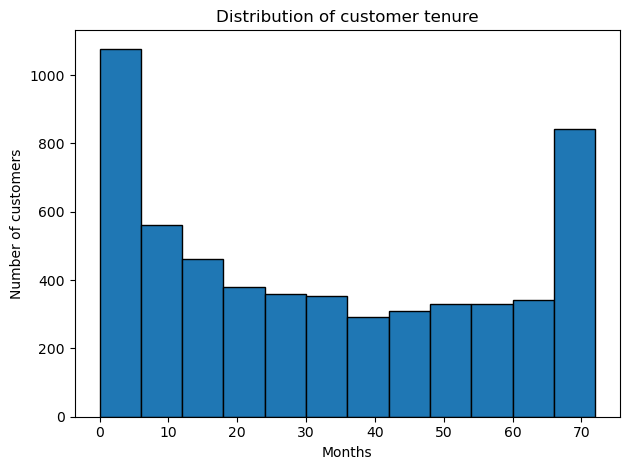


Skewness: 0.24


In [6]:
# Analyzing histogram to understand distribution
tenure_ax = df_numerical['tenure'].plot(
    kind='hist',
    bins=12,
    edgecolor='black',
    linewidth=1,
)
tenure_ax.grid(False)
tenure_ax.set_ylabel('Number of customers')
tenure_ax.set_xlabel('Months')
tenure_ax.set_title('Distribution of customer tenure')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_histogram',
)
plt.show()

# Calculating skewness to assess asymmetry
tenure_skew = df_numerical['tenure'].skew()
print(f'\nSkewness: {tenure_skew.round(2)}')

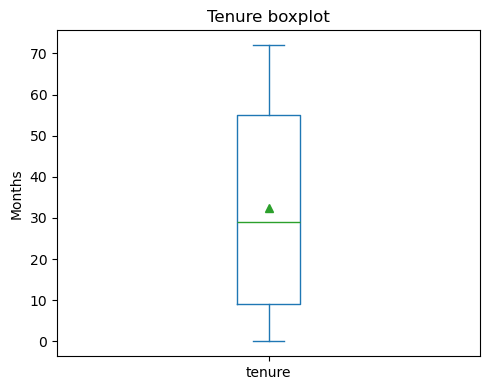

In [7]:
# Visualizing tenure spread and potential outliers
tenure_boxplot = df_numerical['tenure'].plot(
    kind='box',
    figsize=(5,4),
    showmeans=True,
)
tenure_boxplot.set_title('Tenure boxplot')
tenure_boxplot.set_ylabel('Months')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_boxplot',
)
plt.show()

In [8]:
tenure_outliers_report = iqr_outliers(
    df=df_numerical,
    column='tenure',
)
tenure_outliers_report

Outliers below lower bound: 0
Outliers above upper bound: 0


In [9]:
# Comparing tenure statistics between churn groups
tenure_by_churn_stats = groupby_stats(
    df=df_numerical,
    group_column=TARGET_COLUMN,
    column='tenure',
)
tenure_by_churn_stats

,count,mean,median,q1,q3
churn,,,,,
No,4139,37.67,38.0,15.0,61.0
Yes,1495,18.12,10.0,2.0,29.0


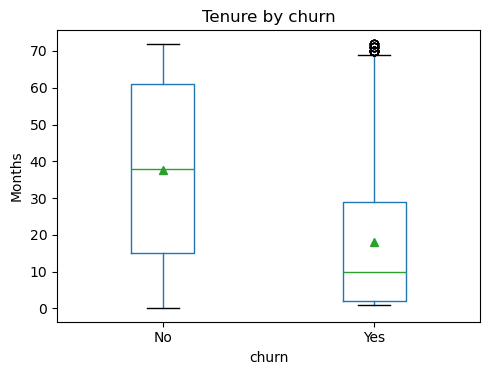

In [10]:
# Visualizing tenure distribution by churn status
tenure_by_churn_boxplot = df_numerical.boxplot(
    column='tenure',
    by='churn',
    figsize=(5, 4),
    widths=0.3,
    showmeans=True,
    grid=False,
)
fig = tenure_by_churn_boxplot.get_figure()
fig.suptitle(None)
tenure_by_churn_boxplot.set_title('Tenure by churn')
tenure_by_churn_boxplot.set_ylabel('Months')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_by_churn_boxplot',
)
plt.show()

In [11]:
# Calculate churn rate by tenure bins
tenure_bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 73]

tenure_churn_rate = churn_rate_per_bin(
    df=df_numerical,
    column='tenure',
    target_column=TARGET_COLUMN,
    bins=tenure_bins,
    baseline_rate=baseline_churn_rate,
)
tenure_churn_rate

,bins,customers,churn_rate,diff_from_churn_rate_baseline
0,"[0, 6)",1077,55.06,28.52
1,"[6, 12)",562,37.19,10.65
2,"[12, 18)",461,32.32,5.78
3,"[18, 24)",379,24.27,-2.27
4,"[24, 30)",358,23.46,-3.08
5,"[30, 36)",353,19.83,-6.71
6,"[36, 42)",292,19.86,-6.68
7,"[42, 48)",310,18.39,-8.15
8,"[48, 54)",329,16.11,-10.43
9,"[54, 60)",330,14.24,-12.30


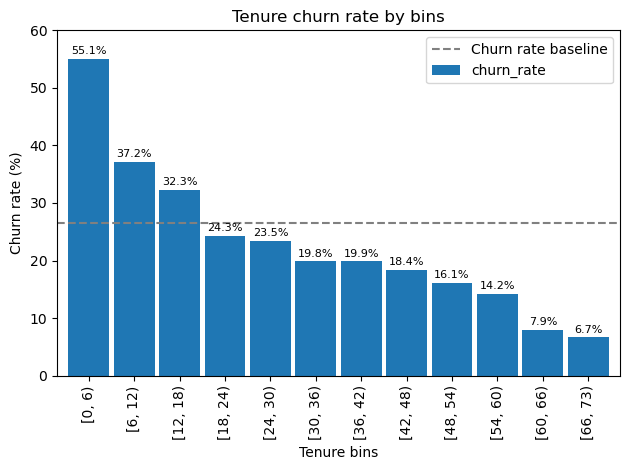

In [12]:
# Visualizing churn rate across tenure bins
tenure_churn_rate_ax = tenure_churn_rate.plot(
    kind='bar',
    x='bins',
    y='churn_rate',
    width=0.9,
)
add_bar_labels(axes=tenure_churn_rate_ax)
tenure_churn_rate_ax.axhline(
    y=baseline_churn_rate,
    color='grey',
    linestyle='--',
    label='Churn rate baseline'
)
tenure_churn_rate_ax.set_title('Tenure churn rate by bins')
tenure_churn_rate_ax.set_xlabel('Tenure bins')
tenure_churn_rate_ax.set_ylabel('Churn rate (%)')
tenure_churn_rate_ax.legend()
tenure_churn_rate_ax.set_ylim(0, 60)
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='tenure_churn_rate_by_bins',
)
plt.show()

### Summary

Tenure ranges from 0 to 72 months, with a mean of 32.5 and a median of 29 months. The distribution is widely spread and slightly right-skewed, with noticeable concentrations among very new and very long-term customers. No potential outliers were detected using the IQR method.

Customers who churned have clearly lower tenure than non-churners. Their median tenure is 10 months compared with 38 months for non-churners, and their interquartile range is shifted toward lower values.

Churn rate is above the overall baseline in the first three tenure bins and decreases as tenure increases. This suggests that customers in the early stage of their relationship with the company represent a higher-risk segment and may be especially important for retention analysis.

## Column: `monthly_charges`

In [13]:
monthly_charges_stats = descriptive_stats(
    df=df_numerical,
    column='monthly_charges',
)
monthly_charges_stats

count      5634.000000
mean         65.002689
std          30.157831
min          18.400000
25%          35.650000
50%          70.650000
75%          89.950000
max         118.750000
iqr          54.300000
nunique    1497.000000
Name: monthly_charges, dtype: float64

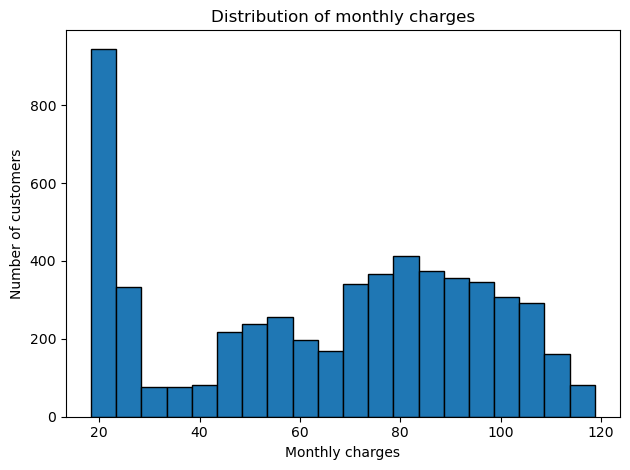


Skewness: -0.23


In [15]:
# Analyzing histogram to understand distribution
monthly_charges_ax = df_numerical['monthly_charges'].plot(
    kind='hist',
    bins=20,
    edgecolor='black',
    linewidth=1,
)
monthly_charges_ax.set_title('Distribution of monthly charges')
monthly_charges_ax.set_xlabel('Monthly charges')
monthly_charges_ax.set_ylabel('Number of customers')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='monthly_charges_histogram',
)
plt.show()

# Calculating skewness to assess asymmetry
monthly_charges_skew = df_numerical['monthly_charges'].skew()
print(f'\nSkewness: {monthly_charges_skew.round(2)}')

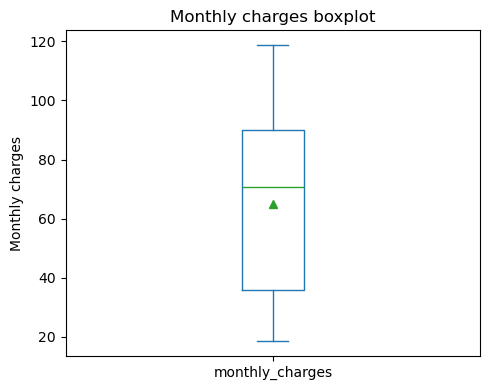

In [16]:
# Visualizing monthly charges spread and potential outliers
monthly_charges_boxplot = df_numerical['monthly_charges'].plot(
    kind='box',
    figsize=(5, 4),
    showmeans=True,
)
monthly_charges_boxplot.set_title('Monthly charges boxplot')
monthly_charges_boxplot.set_ylabel('Monthly charges')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='monthly_charges_boxplot',
)
plt.show()

In [17]:
monthly_charges_outliers_report = iqr_outliers(
    df=df_numerical,
    column='monthly_charges',
)
monthly_charges_outliers_report

Outliers below lower bound: 0
Outliers above upper bound: 0


In [18]:
# Comparing monthly charges statistics between churn groups
monthly_charges_by_churn_stats = groupby_stats(
    df=df_numerical,
    group_column=TARGET_COLUMN,
    column='monthly_charges',
)
monthly_charges_by_churn_stats

,count,mean,median,q1,q3
churn,,,,,
No,4139,61.58,64.95,25.10,88.82
Yes,1495,74.49,79.85,55.92,94.22


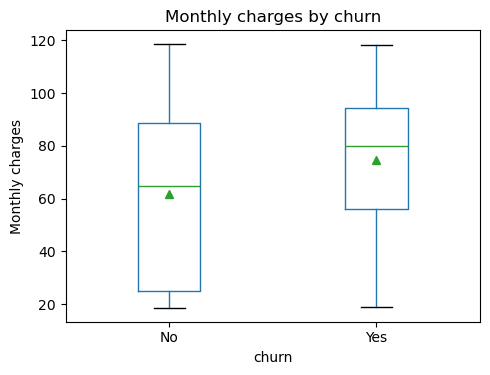

In [19]:
# Visualizing monthly charges distribution by churn status
monthly_charges_by_churn_boxplot = df_numerical.boxplot(
    column='monthly_charges',
    by='churn',
    figsize=(5, 4),
    widths=0.3,
    showmeans=True,
    grid=False,
)
fig = monthly_charges_by_churn_boxplot.get_figure()
fig.suptitle(None)
monthly_charges_by_churn_boxplot.set_title('Monthly charges by churn')
monthly_charges_by_churn_boxplot.set_ylabel('Monthly charges')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='monthly_cahrges_by_churn_boxplot',
)
plt.show()

In [20]:
# Calculate churn rate by monthly charges bins
monthly_charges_bins = [0, 20, 40, 60, 80, 100, 120]

monthly_charges_churn_rate = churn_rate_per_bin(
    df=df_numerical,
    column='monthly_charges',
    target_column=TARGET_COLUMN,
    bins=monthly_charges_bins,
    baseline_rate=baseline_churn_rate,
)
monthly_charges_churn_rate

,bins,customers,churn_rate,diff_from_churn_rate_baseline
0,"[0, 20)",480,8.54,-18.00
1,"[20, 40)",985,13.30,-13.24
2,"[40, 60)",841,26.16,-0.38
3,"[60, 80)",1152,31.51,4.97
4,"[80, 100)",1436,37.12,10.58
5,"[100, 120)",740,27.97,1.43


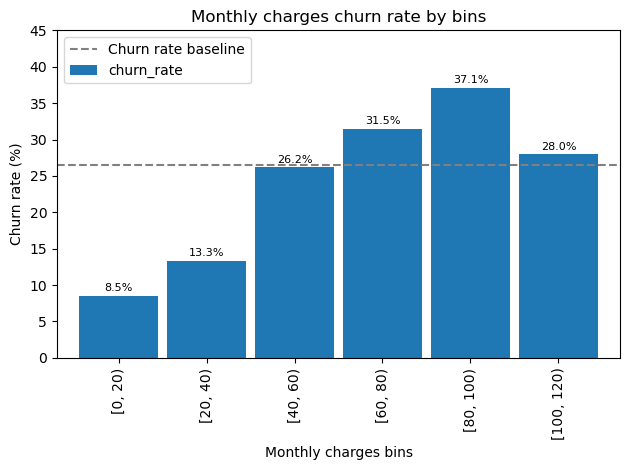

In [21]:
# Visualizing churn rate across monthly charges bins
monthly_charges_churn_rate_ax = monthly_charges_churn_rate.plot(
    kind='bar',
    x='bins',
    y='churn_rate',
    width=0.9,
)
add_bar_labels(axes=monthly_charges_churn_rate_ax)
monthly_charges_churn_rate_ax.axhline(
    y=baseline_churn_rate,
    color='grey',
    linestyle='--',
    label='Churn rate baseline',
)
monthly_charges_churn_rate_ax.set_ylim(0, 45)
monthly_charges_churn_rate_ax.set_title('Monthly charges churn rate by bins')
monthly_charges_churn_rate_ax.set_xlabel('Monthly charges bins')
monthly_charges_churn_rate_ax.set_ylabel('Churn rate (%)')
monthly_charges_churn_rate_ax.legend()
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='monthly_charges_churn_rate_by_bins',
)
plt.show()

### Summary

Monthly charges range from USD 18.40 to USD 118.75. The median is USD 70.65, which is higher than the mean of USD 65, suggesting slight negative skewness.

The histogram shows a large concentration of customers with low monthly charges and a broader concentration at higher charge levels.

No potential outliers were detected using the IQR method.

Non-churners show a wider spread and include more customers with lower monthly charges, while churners tend to have higher monthly charges.

Churn rate is low for customers with lower monthly charges and shows an increasing trend, reaching the highest level for monthly charges between USD 80 and USD 100. 

For monthly charges between USD 100 and USD 120, churn rate decreases and is close to the overall churn rate baseline.

## Column: `total_charges`

In [22]:
total_charges_stats = descriptive_stats(
    df=df_numerical,
    column='total_charges',
)
total_charges_stats

count      5634.000000
mean       2297.987859
std        2278.865564
min           0.000000
25%         404.237500
50%        1401.000000
75%        3841.637500
max        8684.800000
iqr        3437.400000
nunique    5286.000000
Name: total_charges, dtype: float64

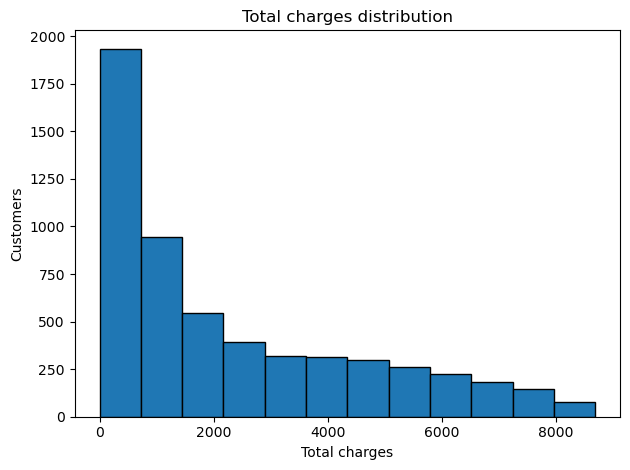


Skewness: 0.96


In [23]:
# Analyzing histogram to understand distribution
total_charges_ax = df_numerical['total_charges'].plot(
    kind='hist',
    bins=12,
    edgecolor='black',
    linewidth=1,
)
total_charges_ax.set_title('Total charges distribution')
total_charges_ax.set_xlabel('Total charges')
total_charges_ax.set_ylabel('Customers')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='total_charges_histogram',
)
plt.show()

# Calculating skewness to assess asymmetry
total_charges_skew = df_numerical['total_charges'].skew()
print(f'\nSkewness: {total_charges_skew.round(2)}')

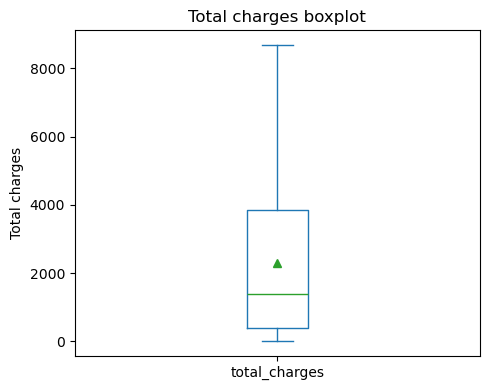

In [24]:
# Visualizing total charges spread and potential outliers
total_charges_boxplot = df_numerical['total_charges'].plot(
    kind='box',
    figsize=(5, 4),
    showmeans=True,
)
total_charges_boxplot.set_title('Total charges boxplot')
total_charges_boxplot.set_ylabel('Total charges')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='total_charges_boxplot',
)
plt.show()

In [25]:
total_charges_outliers_report = iqr_outliers(
    df=df_numerical,
    column='total_charges',
)
total_charges_outliers_report

Outliers below lower bound: 0
Outliers above upper bound: 0


In [26]:
# Comparing total charges statistics between churn groups
total_charges_by_churn_stats = groupby_stats(
    df=df_numerical,
    group_column=TARGET_COLUMN,
    column='total_charges',
)
total_charges_by_churn_stats

,count,mean,median,q1,q3
churn,,,,,
No,4139,2568.95,1697.70,588.35,4279.98
Yes,1495,1547.82,703.55,134.43,2346.55


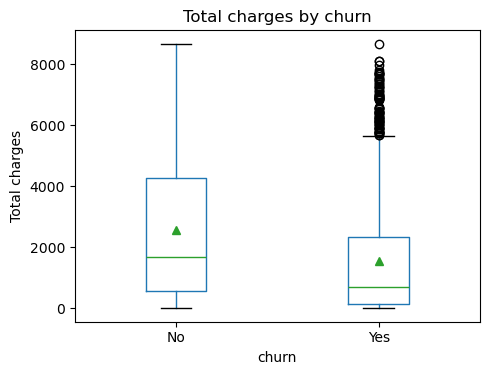

In [27]:
# Visualizing monthly charges distribution by churn status
total_charges_by_churn_boxplot = df_numerical.boxplot(
    column='total_charges',
    by='churn',
    figsize=(5,4),
    widths=0.3,
    showmeans=True,
    grid=False,
)
fig = total_charges_by_churn_boxplot.get_figure()
fig.suptitle(None)
total_charges_by_churn_boxplot.set_title('Total charges by churn')
total_charges_by_churn_boxplot.set_ylabel('Total charges')
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='total_charges_by_churn_boxplot',
)
plt.show()

In [28]:
# Calculate churn rate by total charges bins
total_charges_bins = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]

total_charges_churn_rate = churn_rate_per_bin(
    df=df_numerical,
    column='total_charges',
    target_column=TARGET_COLUMN,
    bins=total_charges_bins,
    baseline_rate=baseline_churn_rate,
)
total_charges_churn_rate

,bins,customers,churn_rate,diff_from_churn_rate_baseline
0,"[0, 1000)",2317,37.03,10.49
1,"[1000, 2000)",1016,20.67,-5.87
2,"[2000, 3000)",525,27.05,0.51
3,"[3000, 4000)",442,18.10,-8.44
4,"[4000, 5000)",414,18.12,-8.42
5,"[5000, 6000)",361,16.34,-10.20
6,"[6000, 7000)",282,14.89,-11.65
7,"[7000, 8000)",211,12.32,-14.22
8,"[8000, 9000)",66,4.55,-21.99


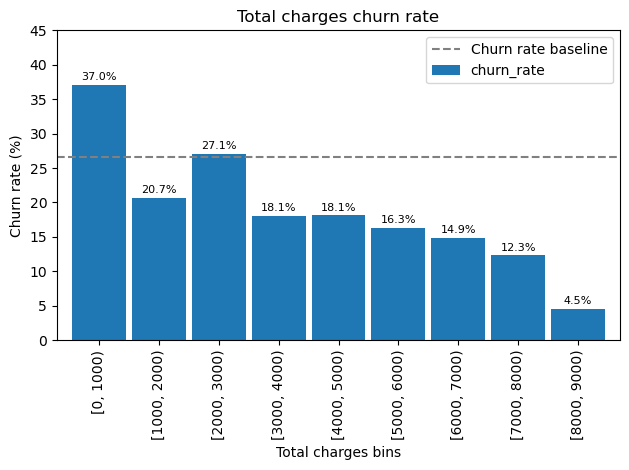

In [29]:
# Visualizing churn rate across total charges bins
total_charges_churn_rate_ax = total_charges_churn_rate.plot(
    kind='bar',
    x='bins',
    y='churn_rate',
    width=0.9
)
add_bar_labels(axes=total_charges_churn_rate_ax)
total_charges_churn_rate_ax.axhline(
    y=baseline_churn_rate,
    color='grey',
    linestyle='--',
    label='Churn rate baseline',
)
total_charges_churn_rate_ax.set_ylim(0, 45)
total_charges_churn_rate_ax.set_title('Total charges churn rate')
total_charges_churn_rate_ax.set_xlabel('Total charges bins')
total_charges_churn_rate_ax.set_ylabel('Churn rate (%)')
total_charges_churn_rate_ax.legend()
plt.tight_layout()
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='total_charges_churn_rate_by_bins',
)
plt.show()

### Summary

Total charges range from USD 0 to USD 8684.80, with a mean of USD 2297.99, which is higher than the median of USD 1401.00.

The histogram shows a large concentration of customers with low total charges and a decreasing frequency toward higher values, resulting in a right-skewed distribution.

No potential outliers were detected using the IQR method. 

The middle 50% of non-churners is shifted toward higher total charges compared with churners. Churners tend to have lower total charges, although the group also includes customers with relatively high total charges.

Customers with total charges between USD 0 and USD 999 have the highest churn rate, 10.49 percentage points above the overall baseline. Churn rate generally decreases at higher total charge levels, with the lowest observed rate in the highest bin.

## Relationships between numerical features

In [30]:
# Correlation matrix
df_numerical_corr = df_numerical[['tenure', 'monthly_charges', 'total_charges']].copy()
df_numerical_corr['churn_num'] = encode_churn(
    df=df_numerical,
    target_column=TARGET_COLUMN,
)

corr_matrix = df_numerical_corr.corr().round(2)
corr_matrix

,tenure,monthly_charges,total_charges,churn_num
tenure,1.00,0.25,0.83,-0.35
monthly_charges,0.25,1.00,0.65,0.19
total_charges,0.83,0.65,1.00,-0.20
churn_num,-0.35,0.19,-0.20,1.00


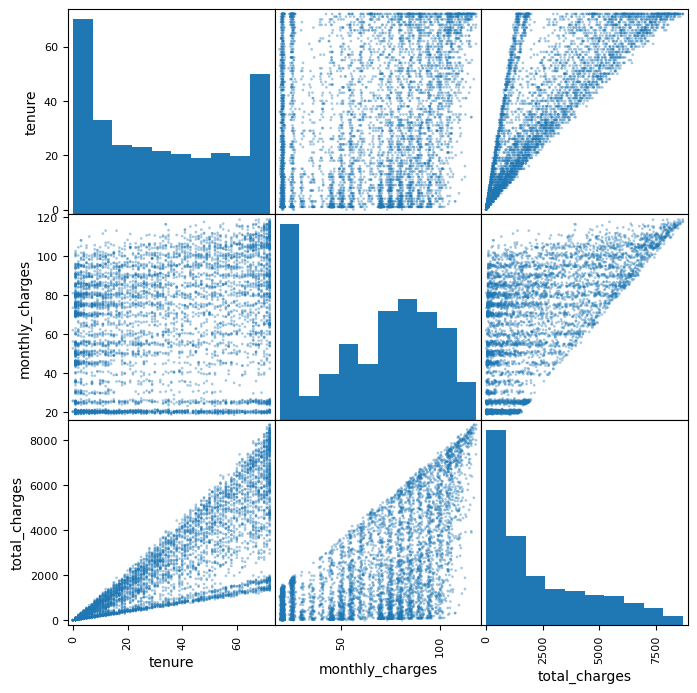

In [31]:
# Scatter plots
scatter_matrix_axes = scatter_matrix(
    df_numerical[['tenure', 'monthly_charges', 'total_charges']],
    figsize=(8, 8),
    alpha=0.4,
    s=15,
)
save_plot(
    path=EDA_NUMERICAL_DIR,
    file_name='scatter_matrix',
)
plt.show()

## Summary

Numerical features contain no missing values and no potential outliers in their overall distributions.

EDA shows that the highest-risk customer segment consists of customers with low tenure, especially 0–5 months, where the churn rate reaches 55.1%, which is 28.56 percentage points above the baseline.

Other higher-risk segments include customers with monthly charges between USD 60 and USD 99 and customers with total charges between USD 0 and USD 999.

Analysis of relationships between numerical features showed a strong positive correlation between tenure and total charges, and a moderate positive correlation between monthly charges and total charges.